# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is "linear" if its parameters are linear. The core formula is $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_kx_k$, meaning the output is a weighted sum of inputs plus a constant. The predictor variables ($x$) do not have to be linear. For example, $y = \beta_0 + \beta_1 x^2$ is still a linear model because the relationship between $y$ and $\beta_1$ is linear, even though the relationship between $y$ and $x$ is quadratic. 
2. We interpret the coefficient for a dummy variable as the expected change in the outcome $y$ compared to the reference group (the category left out of the encoding). In one-hot encoding, we drop the "baseline" category. Then, the model intercept represents the mean value of the response variable for that baseline category. 
3. Linear regression can be used for classification by applying a threshold to the continuous output (ex: values > 0.5 are Class 1, < 0.5 are Class 0). However, it should not be used for classification because it may predict probabilities less than 0 or greater than 1 and is performs far better for regression tasks. 
4. Signs that your linear model is over-fitting have high variance but low bias, leading to high expected loss. The model will have very low error on the training set but a much higher error on the test set. Finally, the model captures a lot of noise rather than the general trend. 
5. Multi-colinearity is the tendency of highly correlated variables to cancel one another out, and give the model an unexpected "mushy" and "high variance" quality. In the two-stage least squares technique, we pick a a variable $x_k$. We regress $y$ and $x_k$ on all of the other variables in the regression, and save the residuals, $r_y$ and $r_{x_k}$. For the second stage, we run single linear regression of $r_y$ on $r_{x_k}$. The slope coefficient has the same value as $\hat{b}_k$. If multi-colinearity exists between your variables or within the first stage, the "predicted values" won't contain enough unique information, causing the standard errors in the second stage to explode and making your estimates unstable.
6. You can capture nonlinear trends while keeping the model mathematically "linear" by:
- Polynomial Transformation: Adding terms like $x^2$ or $x^3$
- Interaction Terms: Adding $x_1 \cdot x_2$ to see how variables affect each other
- Logarithmic Transformations: Applying $\log(x)$ or $\log(y)$ to handle exponential growth or diminishing returns
- Basis Functions: Using splines or step functions to allow the model to change slope at specific "knots"
7. The slope coefficient ($\beta_1$) represents the average change in the response variable $y$ for every one-unit increase in the predictor $x$, holding all other variables in the model constant.
8. In a train/test split, the data is split once into two sets, a training set and a test set (often 80%/20%). This results in high variance as the results depend heavily on how the split was made. It can be done quickly because only one model is trained. However. $k$-fold cross validation splits the data into $k$ subsets, and the model is trained $k$ times. It is more stable because every data point is used for both training and testing, but it is far slower since $k$ separate models must be trained.
9. The value of $k$ is typically chosen based on a balance between computational cost and bias. The standard choice is often $k=5$ or $k=10$. These values are shown to provide a good trade-off where the error estimate is neither too biased nor too variable.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt
Average Price and Rating by Neighbourhood:
                      Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750
The most expensive borough, on average, is Manhattan.


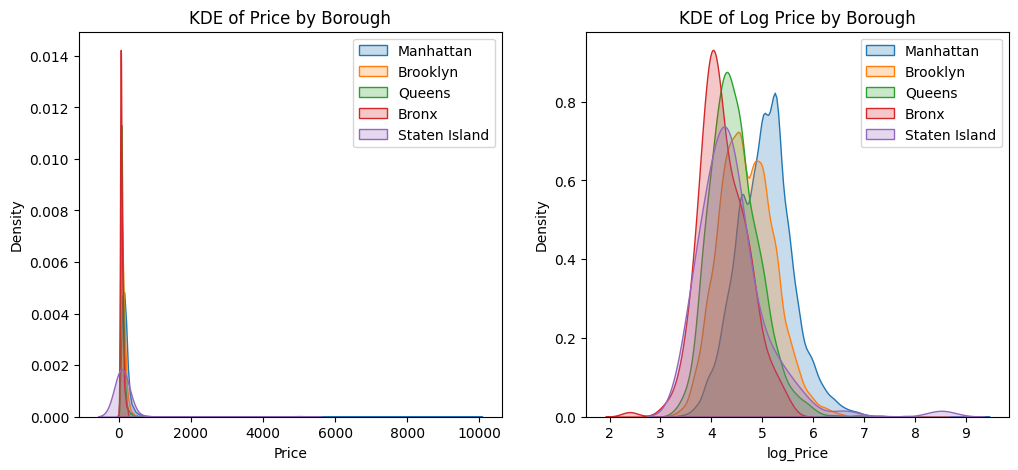

In [115]:
#1
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv('Q1_clean.csv')
print(df.head())

averages = df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print("Average Price and Rating by Neighbourhood:\n", averages)
print("The most expensive borough, on average, is Manhattan.")

df['log_Price'] = np.log(df['Price'] + 1) 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for borough in df['Neighbourhood '].unique():
    sns.kdeplot(df[df['Neighbourhood '] == borough]['Price'], label=borough, fill=True)
plt.title("KDE of Price by Borough")
plt.legend()

plt.subplot(1, 2, 2)
for borough in df['Neighbourhood '].unique():
    sns.kdeplot(df[df['Neighbourhood '] == borough]['log_Price'], label=borough, fill=True)
plt.title("KDE of Log Price by Borough")
plt.legend()

In [116]:
#2
# I will be dropping first category and keeping the intercept. When the intercept is removed, the coefficients are exactly equal to the conditional group means calculated in question 1.
df_borough = pd.get_dummies(df['Neighbourhood '], dtype='int', drop_first=True)
print(df_borough.head())
y = df['Price']

model_a = LinearRegression(fit_intercept=True)
model_a.fit(df_borough, y)

print("Regression Coefficients (Dropped First Category):\n")
print(f"Intercept (Reference Group Mean): {model_a.intercept_:}\n")
coef_summary_a = pd.DataFrame({
    'Borough': df_borough.columns,
    'Coefficient (Diff from Reference)': model_a.coef_
})
print(coef_summary_a)

# The coefficients in the regression are much lower than those of the table from part 1. 
# Each coefficient is ~75 units away from the means from part 1.
# However, the order of most to least expensive remains the same (From most to least: Manhattan, Staten Island, Brooklyn, Queens)

# When dropping the first category, the estimated coefficients are equal to the mean - the intercept (the reference group mean)
# So, for example, the Brooklyn coefficient (52.47)= Brooklyn mean (127.75) - Intercept (Bronx Mean) (75.28).

   Brooklyn  Manhattan  Queens  Staten Island
0         0          1       0              0
1         1          0       0              0
2         0          1       0              0
3         1          0       0              0
4         0          1       0              0
Regression Coefficients (Dropped First Category):

Intercept (Reference Group Mean): 75.27649769584667

         Borough  Coefficient (Diff from Reference)
0       Brooklyn                          52.470881
1      Manhattan                         108.387789
2         Queens                          21.580735
3  Staten Island                          70.890169


In [117]:
#3
X = df[['Review Scores Rating']]
y = df['Price']

model_rs= LinearRegression(fit_intercept=True)
model_rs.fit(X, y)

print(f"Intercept: {model_rs.intercept_}")
print(f"Slope: {model_rs.coef_[0]}")

# For every one-unit increase in the Review Scores Rating, the predicted Price per night, on average, increases by ~$1.02 dollars, holding all else constant.

Intercept: 60.878390657123816
Slope: 1.0208266022674735


In [118]:
#4
X_dummies = pd.get_dummies(df['Neighbourhood '], dtype='int', drop_first=True)
X_both = pd.concat([X_dummies, df[['Review Scores Rating']]], axis=1)
y = df['Price']

model_both = LinearRegression(fit_intercept=True)
model_both.fit(X_both, y)

print(f"Intercept: {model_both.intercept_}")
coef_df = pd.DataFrame({'Variable': X_both.columns, 'Coefficient': model_both.coef_})
print(coef_df)

# The slope coefficient on Review Scores Rating rises by about 0.06. So, for every one-unit increase in Review Scores Rating, predicted Price per night, on average, increases now by ~$1.08 dollars.
# Neighborhood averages do not change in one specific way. 
# Brooklyn lowers by ~1, Manhattan lowers by ~0.1, Queens raises by ~0.1, and Staten Island rises by ~1.

Intercept: -23.812561011677047
               Variable  Coefficient
0              Brooklyn    51.704240
1             Manhattan   108.228737
2                Queens    21.694600
3         Staten Island    71.766552
4  Review Scores Rating     1.081116


In [119]:
#5
neighborhood_dummies = pd.get_dummies(df['Neighbourhood '])
X_interaction = neighborhood_dummies.multiply(df['Review Scores Rating'], axis=0)

model_5 = LinearRegression(fit_intercept=True)
model_5.fit(X_interaction, df['Price'])

results = pd.DataFrame({
    'Neighborhood_Slope': X_interaction.columns,
    'Coefficient': model_5.coef_
})

print(f"Intercept (Base Price): {model_5.intercept_}")
print(results)

# The slopes are different across neighborhoods. 
# They are all below 2, but range from 0.222 to 1.399, which is a big gap. 


Intercept (Base Price): 55.11825364116281
  Neighborhood_Slope  Coefficient
0              Bronx     0.222718
1           Brooklyn     0.790947
2          Manhattan     1.399376
3             Queens     0.456451
4      Staten Island     0.682444


In [121]:
#6
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

score3 = np.sqrt(-cross_val_score(model_rs, X, y, cv=kfold, scoring='neg_mean_squared_error').mean())
score4 = np.sqrt(-cross_val_score(model_both, X_both, y, cv=kfold, scoring='neg_mean_squared_error').mean())
score5 = np.sqrt(-cross_val_score(model_5, X_interaction, y, cv=kfold, scoring='neg_mean_squared_error').mean())

print("RMSE for part 3:", score3)
print("RMSE for part 4:", score4)
print("RMSE for part 5:", score5)

RMSE for part 3: 148.5917641014102
RMSE for part 4: 145.16920261305214
RMSE for part 5: 145.0839669695897


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


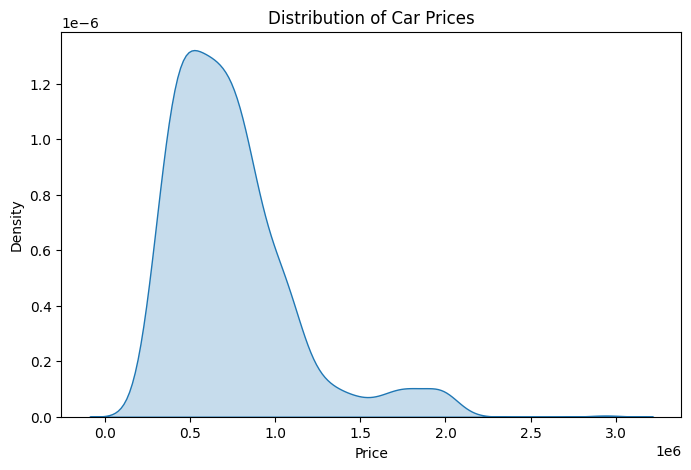

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


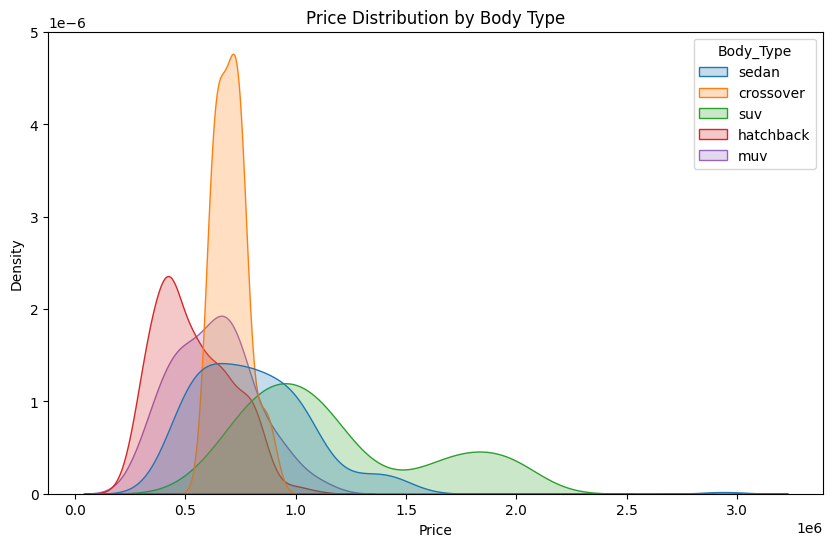

In [ ]:
#1
cars = pd.read_csv('cars_hw.csv')

print(cars['Price'].describe())
plt.figure(figsize=(8, 5))
sns.kdeplot(cars['Price'], fill=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.show()

print(cars.groupby('Body_Type')['Price'].describe())

plt.figure(figsize=(10, 6))
sns.kdeplot(data=cars, x='Price', hue='Body_Type', fill=True, common_norm=False)
plt.title("Price Distribution by Body Type")
plt.xlabel("Price")
plt.show()

# SUVs and sedans are the most expensive
# They also have the most variance


In [ ]:
#2
from sklearn.linear_model import LinearRegression

X_SC = cars[['Seating_Capacity']]
y = cars['Price']

model_SC = LinearRegression().fit(X_SC, y)
print(f"Slope Coefficient: {model_SC.coef_[0]}")

# The slope coefficient represents the average change in price for every one-additional seat added to the car.
# So, as the car gets one more seat, the price, on average, increases by ~ $59,000

X_cat = pd.get_dummies(cars['Seating_Capacity'], drop_first=True)

model_cat = LinearRegression().fit(X_cat, y)
print("Intercept categorical:", model_cat.intercept_)
print("Coefficients:", dict(zip(X_cat.columns, model_cat.coef_)))

# The differences in price are not roughly linear in the number of seats as the coefficients first rise and then begin to fall. 

Slope Coefficient: 59267.9980367217
Intercept categorical: 188000.00000000163
Coefficients: {5: np.float64(546483.8709677402), 6: np.float64(1455999.9999999998), 7: np.float64(735948.7179487178), 8: np.float64(271800.0000000001)}


Optimal number of powers: 3


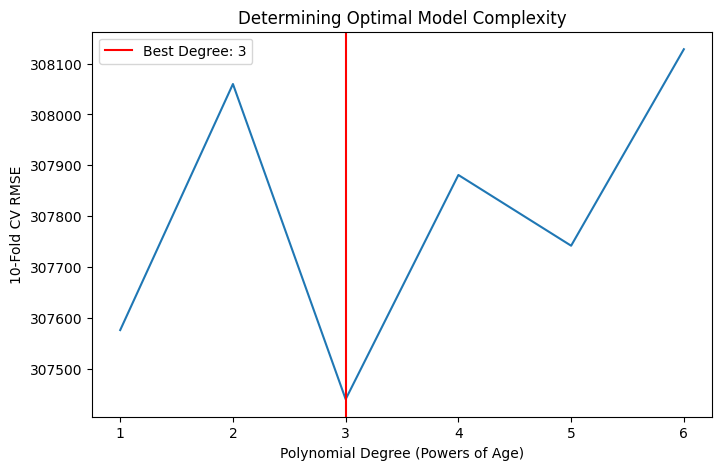

In [81]:
#3
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
cars['Age'] = 2026 - cars['Make_Year']

X = cars[['Age']]
y = cars['Price']

degrees = np.arange(1, 7)
cv_rmse = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=10, scoring='neg_root_mean_squared_error')
    cv_rmse.append(-scores.mean())

best_degree = degrees[np.argmin(cv_rmse)]
print(f"Optimal number of powers: {best_degree}")

plt.figure(figsize=(8, 5))
plt.plot(degrees, cv_rmse)
plt.xlabel('Polynomial Degree (Powers of Age)')
plt.ylabel('10-Fold CV RMSE')
plt.title('Determining Optimal Model Complexity')
plt.axvline(best_degree, color='red', label=f'Best Degree: {best_degree}')
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


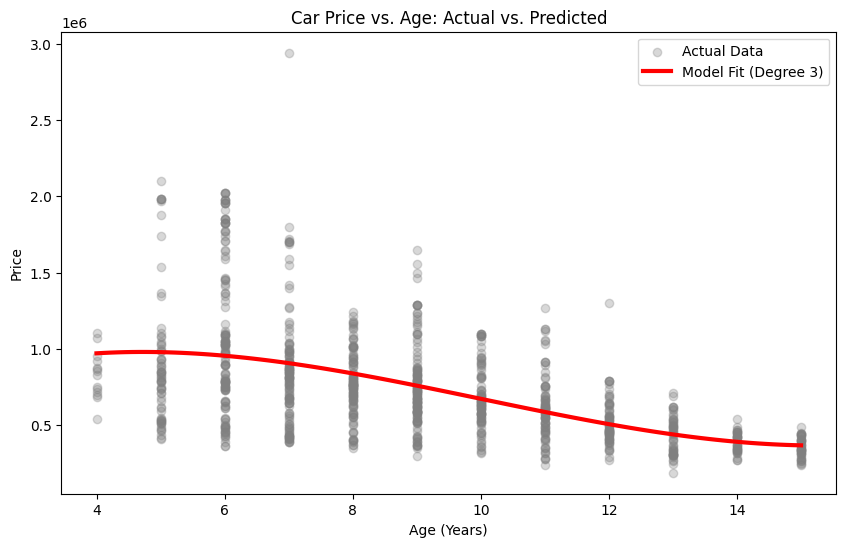

In [85]:
#4
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(cars[['Age']])
y = cars['Price']

model = LinearRegression().fit(X_poly, y)
age_range = np.linspace(cars['Age'].min(), cars['Age'].max(), 100).reshape(-1, 1)
age_range_poly = poly.transform(age_range)
y_pred = model.predict(age_range_poly)

plt.figure(figsize=(10, 6))
plt.scatter(cars['Age'], cars['Price'], alpha=0.3, color='gray', label='Actual Data')
plt.plot(age_range, y_pred, color='red', linewidth=3, label=f'Model Fit (Degree {3})')

plt.title('Car Price vs. Age: Actual vs. Predicted')
plt.xlabel('Age (Years)')
plt.ylabel('Price')
plt.legend()
plt.show()

# The model pretty accurately fits the patterns in the data

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [103]:
#1 
heart = pd.read_csv('heart_hw.csv')
heart.head()

sc = len(heart[(heart['y'] == 1) & (heart['transplant'] == 'control')]) / len(heart[heart['transplant'] == 'control'])
print("Proportion of people who survive in the control group:", sc)

st = len(heart[(heart['y'] == 1) & (heart['transplant'] == 'treatment')]) / len(heart[heart['transplant'] == 'treatment'])
print("Proportion of people who survive in the treatment group:", st)

ATE = st - sc
print("The ATE on 3-year survival for heart transplant interventions is:", ATE)

Proportion of people who survive in the control group: 0.11764705882352941
Proportion of people who survive in the treatment group: 0.34782608695652173
The ATE on 3-year survival for heart transplant interventions is: 0.23017902813299232


In [104]:
#2
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(heart['transplant'], drop_first=True)
y = heart['y']

model = LinearRegression(fit_intercept=True)
model.fit(X, y)

intercept = model.intercept_
coef_treatment = model.coef_[0]

print(f"Intercept: {intercept}")
print(f"Coefficient for Treatment: {coef_treatment}")

# The intercept is equal to the proportion of people who survive in the control group
# The coefficient is equal to the ATE 

Intercept: 0.11764705882352941
Coefficient for Treatment: 0.23017902813299232


Intercept: 0.7019569721740946
Coefficient for Transplant: 0.26470168650367487
Coefficient for Age: -0.013607217160218642


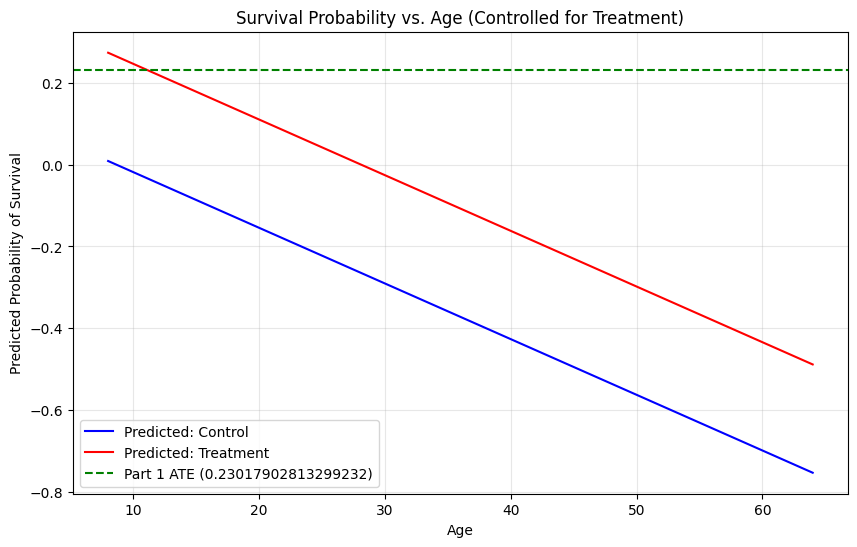

In [105]:
#3
X3 = pd.get_dummies(heart['transplant'], drop_first=True)
X3['age'] = heart['age']
y = heart['y']

model_both = LinearRegression(fit_intercept=True)
model_both.fit(X3, y)

intercept_both = model_both.intercept_
coef_transplant = model_both.coef_[0]
coef_age = model_both.coef_[1]

print(f"Intercept: {intercept_both}")
print(f"Coefficient for Transplant: {coef_transplant}")
print(f"Coefficient for Age: {coef_age}")

# When you control for age, the coefficient on transplant increases by ~0.03
# The intercept represents the predicted probability of survival for a patient in the control group who is 0 years old.
# The transplant coefficient represents the change in survival probability for receiving a transplant, holding age constant.
# The age coefficient represents the change in the probability of survival for every one-year increase in age, holding transplant status constant.

age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

pred_control = intercept + (coef_age * age_range)
pred_treatment = intercept + coef_transplant + (coef_age * age_range)

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control, label='Predicted: Control', color='blue')
plt.plot(age_range, pred_treatment, label='Predicted: Treatment', color='red')
plt.axhline(y=ATE, color='green', linestyle='--', label=f'Part 1 ATE ({ATE})')

plt.xlabel('Age')
plt.ylabel('Predicted Probability of Survival')
plt.title('Survival Probability vs. Age (Controlled for Treatment)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# The ATE under-estimates the impact of a transplant for people under ~11 years old.
# The ATE over-estimates the impact of a transplant for people over ~11 years old.

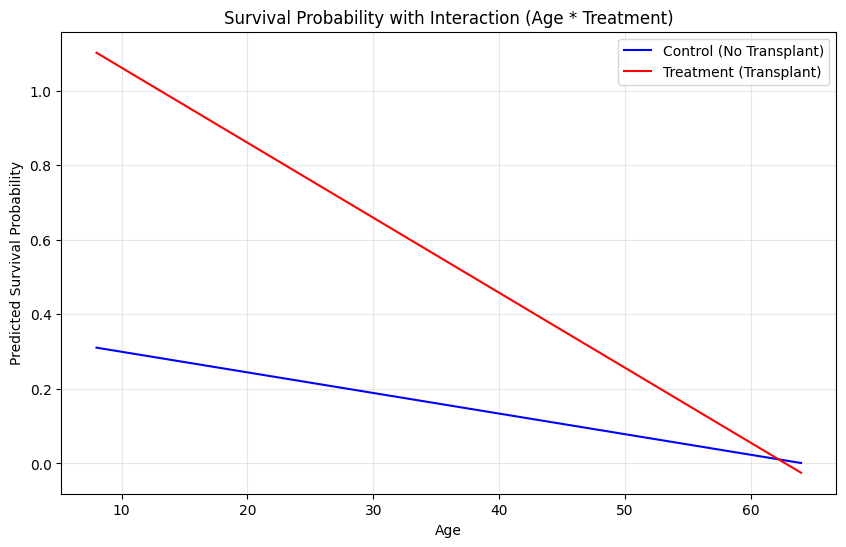

In [106]:
#4
X4 = pd.get_dummies(heart['transplant'], drop_first=True)
X4['age'] = heart['age']
X4['transplant_age_interaction'] = X4['treatment'] * X4['age']
y = heart['y']

model_inter = LinearRegression().fit(X4, y)
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

pred_control = model_inter.intercept_ + (model_inter.coef_[1] * age_range)
pred_treatment = (model_inter.intercept_ + model_inter.coef_[0]) + ((model_inter.coef_[1] + model_inter.coef_[2]) * age_range)

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control, label='Control (No Transplant)', color='blue')
plt.plot(age_range, pred_treatment, label='Treatment (Transplant)', color='red')
plt.title('Survival Probability with Interaction (Age * Treatment)')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#How does allowing age and transplant to interact change your predictions? 
# Allowing age and transplant to interact makes the slope of the treatment group a lot steeper 
# The treatment line and control line now have different angles. 
# The treatment group's line is flatter than the control group's line.
# What pattern do you notice?
# The gap between the survival probability gets much lower with age.
# For younger patients, the gap is large, meaning a transplant helps increase their chances of survival by a lot. 
# For older patients, the gap is smaller, so they are almost likely to survive with or without the transplant. 

In [107]:
#5
from sklearn.model_selection import cross_val_score

score2 = cross_val_score(model, X, y, cv=10, scoring='neg_root_mean_squared_error')
rmse2 = -score2.mean()

score3 = cross_val_score(model_both, X3, y, cv=10, scoring='neg_root_mean_squared_error')
rmse3 = -score3.mean()

score4 = cross_val_score(model_inter, X4, y, cv=10, scoring='neg_root_mean_squared_error')
rmse4 = -score4.mean()

print(f"Model 2 RMSE: {rmse2}")
print(f"Model 3 RMSE: {rmse3}")
print(f"Model 4 RMSE: {rmse4}")

Model 2 RMSE: 0.4354882516721175
Model 3 RMSE: 0.4212428188376608
Model 4 RMSE: 0.41292303632437327


#6
Since this is a linear model, it can predict a survival probability of >1 or <0, which is concerning as probabilities are meant to be between 0 and 1. 
- What does it mean if someone has a -0.4 survival probability and someone else has a -0.1 survival probability? Is one person more dead than another?

Additionally, multicolinearity could cause highly correlated variables to cancel one another out, and give the model an unexpected "mushy" and "high variance" quality. 
- For example, what if age and transplant are very correlated and they cancel one another out?

Finally, is it ethical to only give it to younger people because it may help them more? 